# Importing Libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Datasets

In [7]:
orders = pd.read_csv('../data/processed/orders_cleaned.csv')
order_items = pd.read_csv('../data/processed/order_items_cleaned.csv')
order_payments = pd.read_csv('../data/processed/order_payments_cleaned.csv')
products = pd.read_csv('../data/processed/products_cleaned.csv')
product_category = pd.read_csv('../data/processed/product_category_cleaned.csv')

# Sales Analysis

In [13]:
# Dataframe de vendas
df_sales = orders.merge(order_items, on='order_id', how='inner') 
df_sales = df_sales.merge(order_payments, on='order_id', how='inner')
df_sales = df_sales.merge(products, on='product_id', how='inner')
df_sales = df_sales.merge(product_category, on='product_category_name', how='left')

In [20]:
# Convertendo colunas de data para datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for columns in date_columns:
    if columns in df_sales.columns:
        df_sales[columns] = pd.to_datetime(df_sales[columns])

## 1. Order Volume Over Time

In [36]:
# Qual o volume de pedidos ao longo do tempo?
volume_vendas = df_sales.groupby(df_sales['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique().reset_index()
volume_vendas = volume_vendas[volume_vendas['order_purchase_timestamp'].between('2016-09', '2018-08')]
volume_vendas

,order_purchase_timestamp,order_id
0,2016-09,2
1,2016-10,308
2,2016-12,1
3,2017-01,788
4,2017-02,1733
5,2017-03,2638
6,2017-04,2385
7,2017-05,3660
8,2017-06,3215
9,2017-07,3967


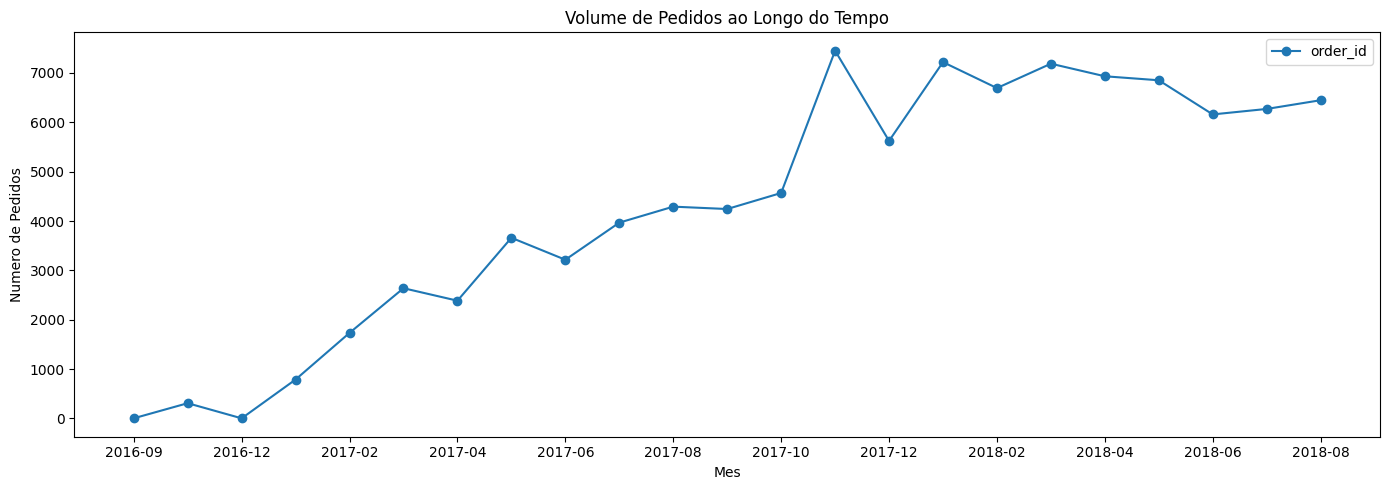

In [45]:
volume_vendas['order_purchase_timestamp'] = volume_vendas['order_purchase_timestamp'].astype(str)

ax = volume_vendas.plot(x='order_purchase_timestamp', y='order_id', kind='line', marker='o', figsize=(14, 5))
plt.title('Volume de Pedidos ao Longo do Tempo')
plt.xlabel('Mes')
plt.ylabel('Numero de Pedidos')
ax.set_xticks(range(0, len(volume_vendas), 2))
ax.set_xticklabels(volume_vendas['order_purchase_timestamp'][::2], rotation=0)
plt.tight_layout()
plt.show()

> **Insight:** novembro de 2017 registrou o maior volume de pedidos (7.451),
> coincidindo com a Black Friday. Evento que deve ser considerado em
> estrategias de estoque e logistica.

## 2. Top Categories by Volume

In [93]:
# Quais categorias vendem mais em quantidade?
categorias_maior_quantidade = df_sales.groupby('product_category_name_english')['product_id'].count().to_frame().sort_values(by='product_id', ascending=False)
categorias_maior_quantidade

,product_id
product_category_name_english,
bed_bath_table,11815
health_beauty,9972
sports_leisure,8945
furniture_decor,8744
computers_accessories,8082
...,...
arts_and_craftmanship,24
la_cuisine,16
cds_dvds_musicals,14


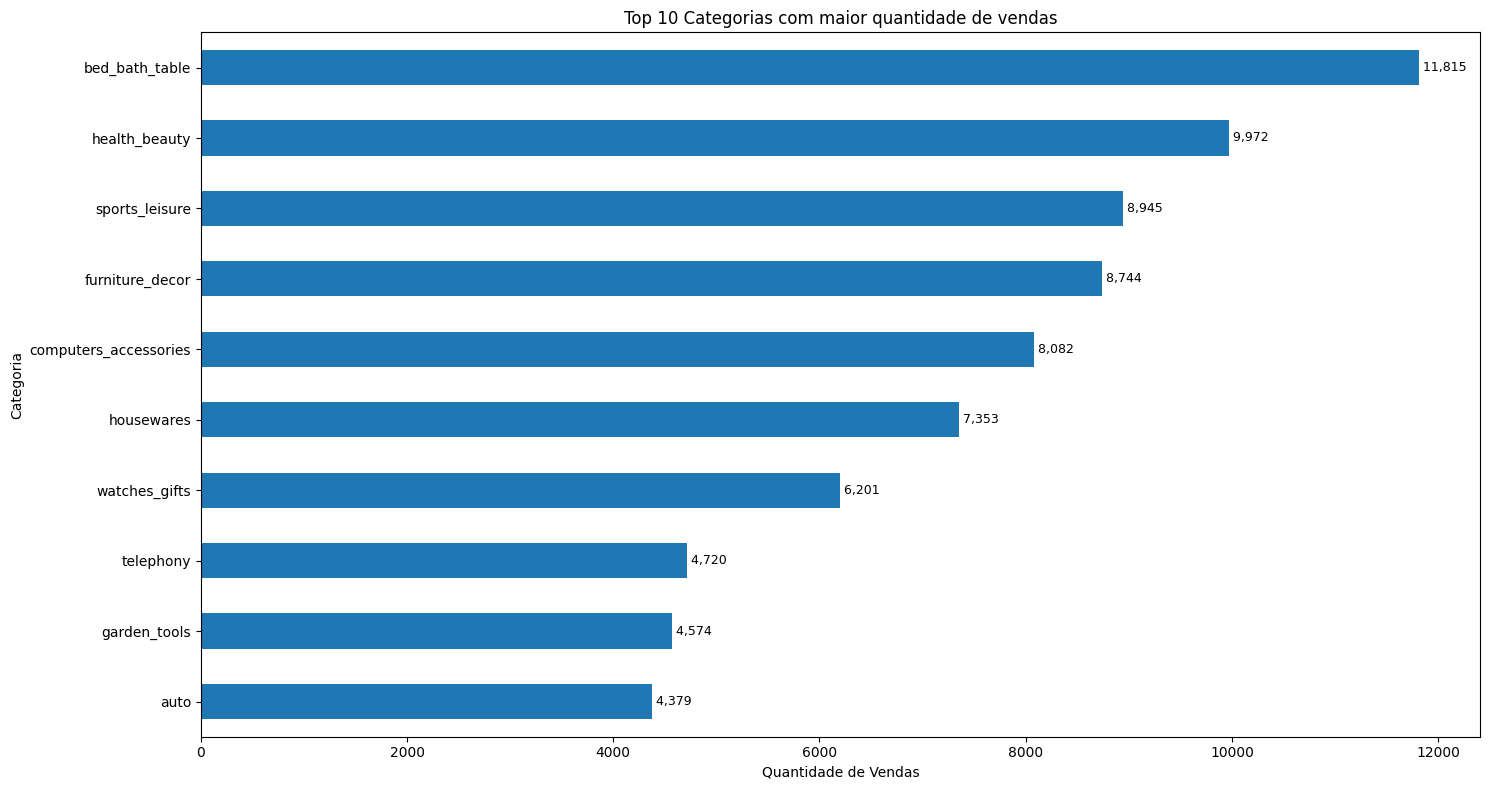

In [113]:
ax = categorias_maior_quantidade.head(10).sort_values(by='product_id', ascending=True).plot(kind='barh', figsize=(15, 8))
plt.title('Top 10 Categorias com maior quantidade de vendas')
plt.xlabel('Quantidade de Vendas')
plt.ylabel('Categoria')
plt.legend().remove()

for bar in ax.patches:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f' {int(bar.get_width()):,}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 3. Top Categories by Revenue

In [62]:
# Quais categorias geram mais receita?
categorias_maior_receita = df_sales.groupby('product_category_name_english')['payment_value'].sum().to_frame().sort_values(by='payment_value', ascending=False)
categorias_maior_receita

,payment_value
product_category_name_english,
bed_bath_table,1710872.33
health_beauty,1657373.12
computers_accessories,1585330.45
furniture_decor,1430176.39
watches_gifts,1429216.68
...,...
flowers,2213.01
home_comfort_2,1710.54
cds_dvds_musicals,1199.43


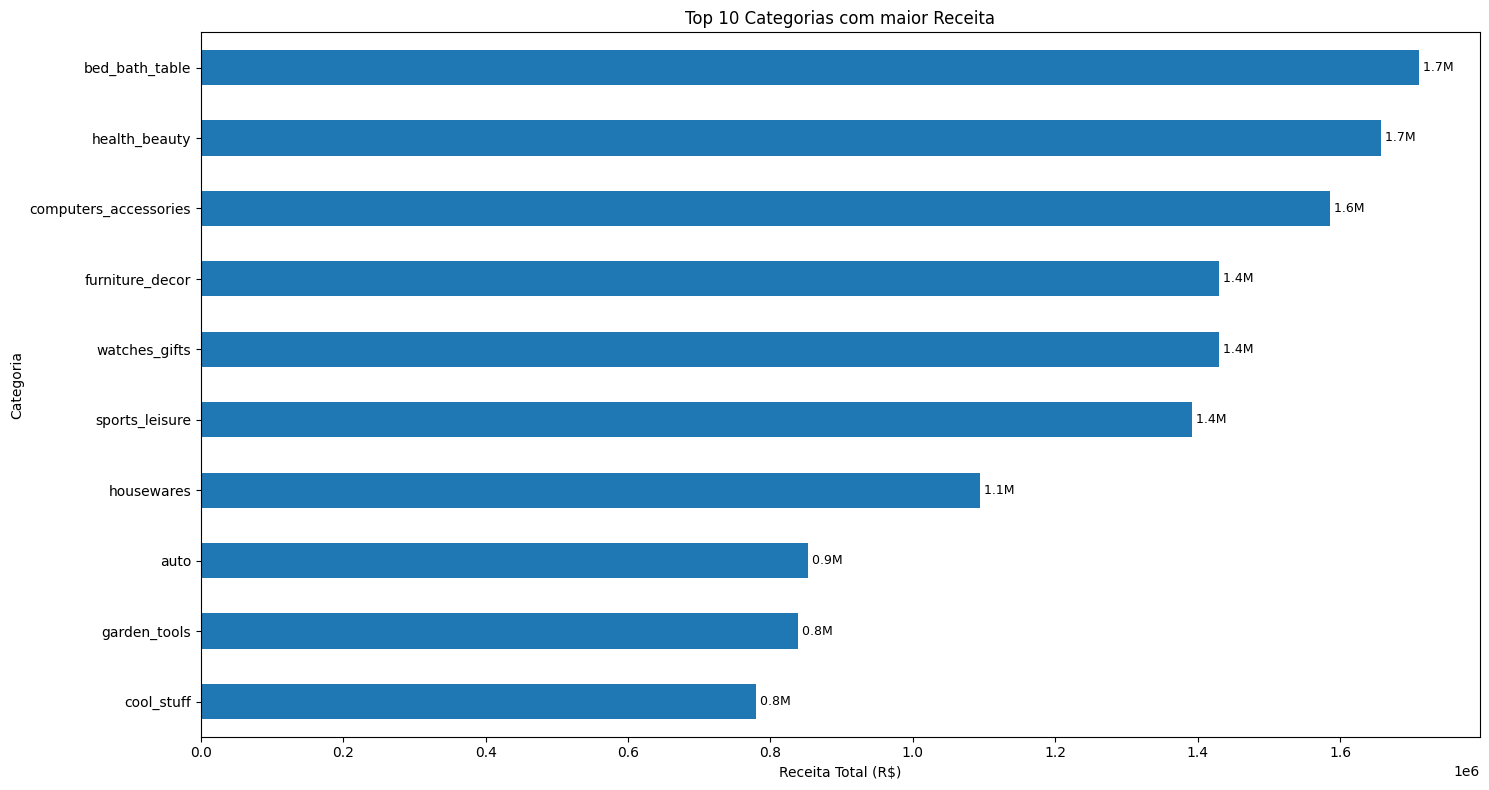

In [112]:
ax = categorias_maior_receita.head(10).sort_values(by='payment_value', ascending=True).plot(kind='barh', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f' {bar.get_width()/1e6:.1f}M',
        va='center',
        ha='left',
        fontsize=9
    )

plt.title('Top 10 Categorias com maior Receita')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Categoria')
plt.legend().remove()
plt.tight_layout()
plt.show()

## 4. Average Ticket by Category

In [102]:
# Qual o ticket medio por categoria?
ticket_medio = (df_sales.drop_duplicates(subset=['order_id', 'payment_value'])
    .groupby('product_category_name_english')['payment_value']
    .mean()
    .to_frame()
    .sort_values(by='payment_value', ascending=False))

ticket_medio

,payment_value
product_category_name_english,
computers,1205.929005
small_appliances_home_oven_and_coffee,652.161299
home_appliances_2,487.442253
agro_industry_and_commerce,376.734567
musical_instruments,324.616481
...,...
cds_dvds_musicals,79.582500
food,79.397259
diapers_and_hygiene,79.306296


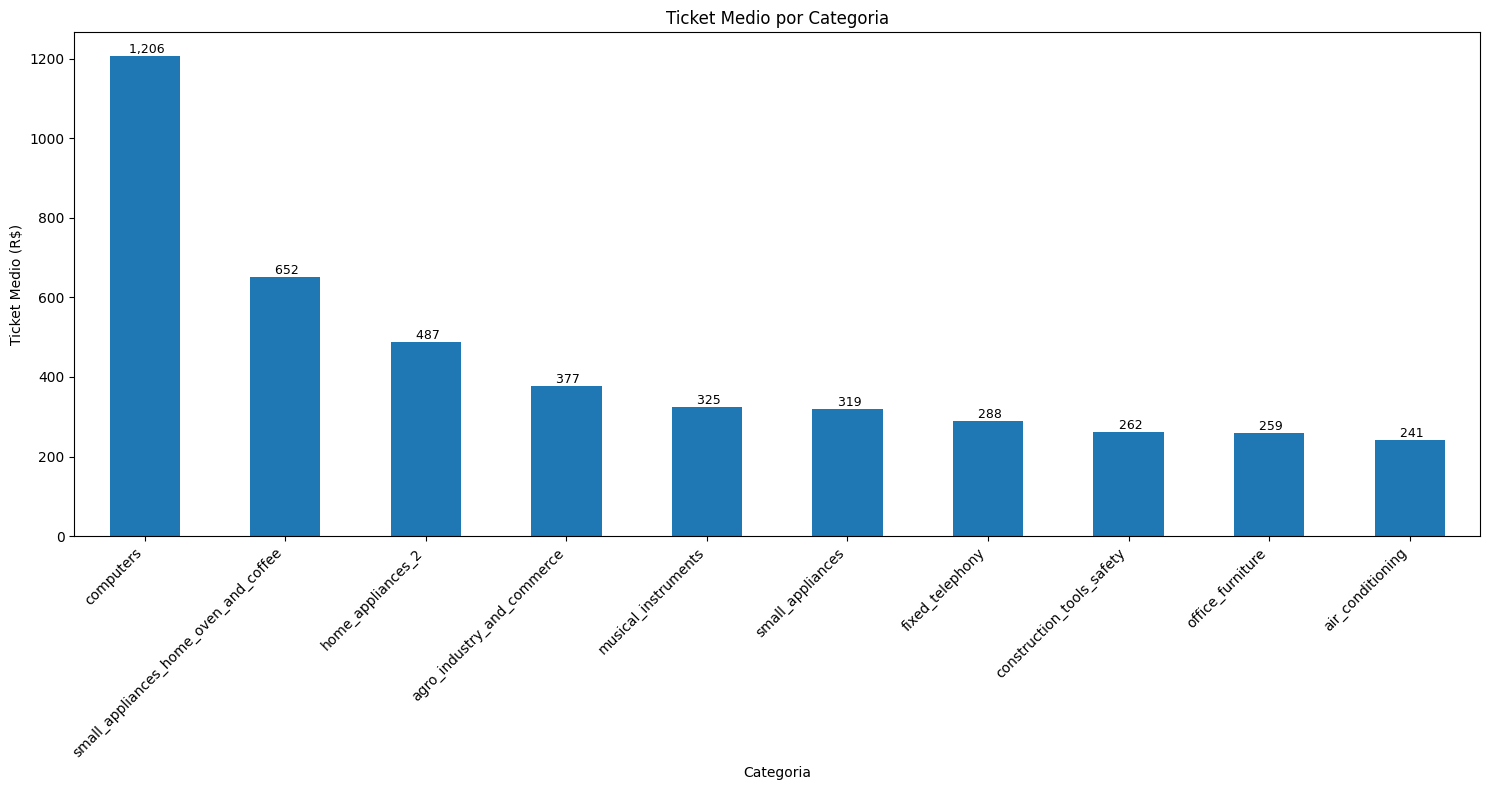

In [109]:
ax = ticket_medio.head(10).sort_values(by='payment_value', ascending=False).plot(kind='bar', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                
        f' {bar.get_height():,.0f}',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.title('Ticket Medio por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Ticket Medio (R$)')
plt.xticks(rotation=45, ha='right')
plt.legend().remove()
plt.tight_layout()
plt.show()

## 5. Payment Methods

In [124]:
# Quais os metodos de pagamento mais usados?
metodos_pagamento = df_sales.drop_duplicates(subset=['order_id', 'payment_type']).groupby('payment_type')['order_id'].nunique().to_frame().sort_values(by='order_id', ascending=False)
metodos_pagamento

,order_id
payment_type,
credit_card,75971
boleto,19610
voucher,3765
debit_card,1521


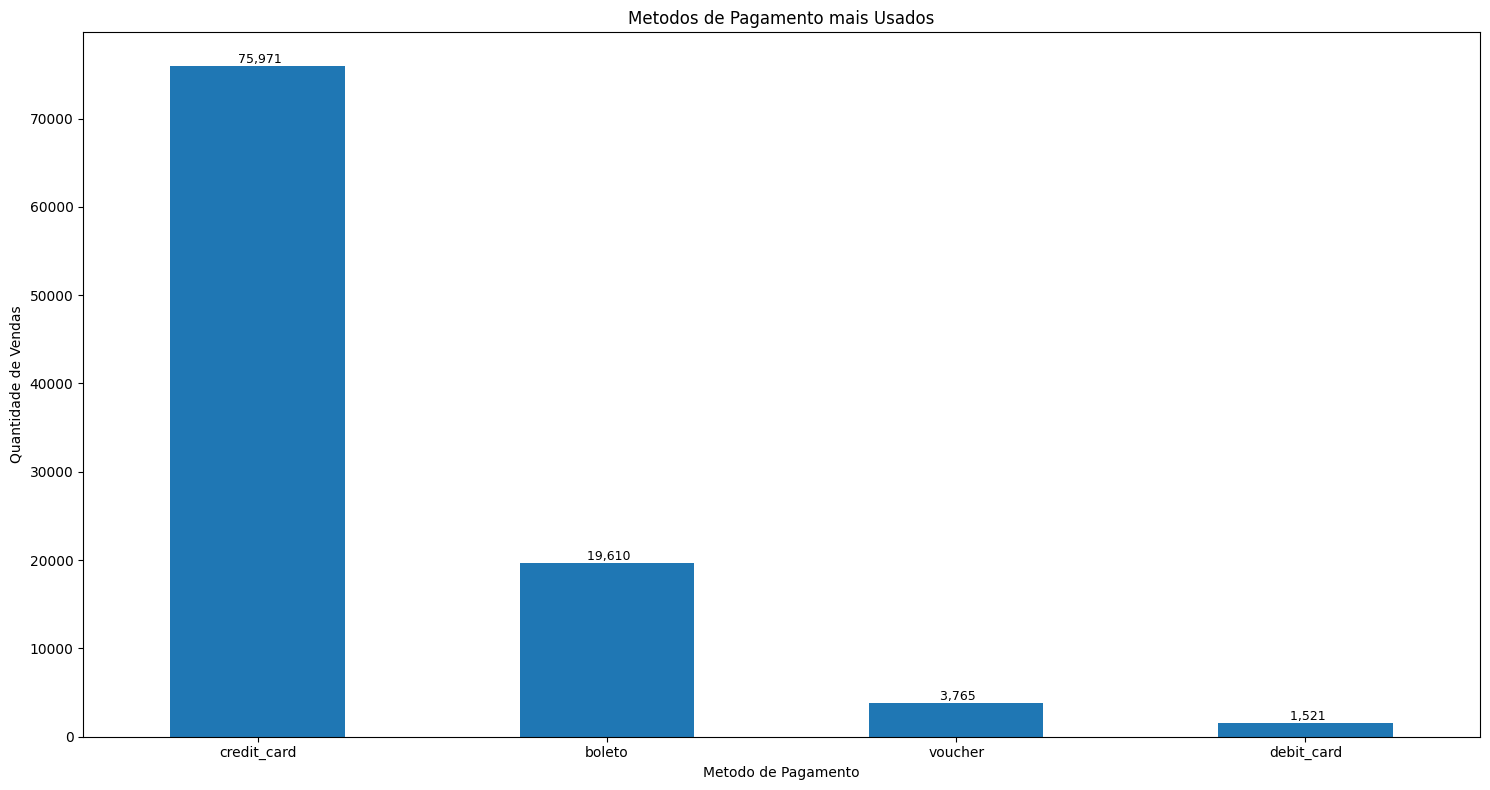

In [129]:
ax = metodos_pagamento.sort_values(by='order_id', ascending=False).plot(kind='bar', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                
        f' {bar.get_height():,.0f}',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.title('Metodos de Pagamento mais Usados')
plt.xlabel('Metodo de Pagamento')
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=0, ha='center')
plt.legend().remove()
plt.tight_layout()
plt.show()

## 6. Installments Distribution

In [133]:
# Qual a distribuicao de parcelamentos?
parcelamentos = df_sales.drop_duplicates(subset=['order_id', 'payment_installments']).groupby('payment_installments')['order_id'].nunique().to_frame().sort_values(by='payment_installments', ascending=False)
parcelamentos

,order_id
payment_installments,
24,18
23,1
22,1
21,3
20,17
18,27
17,7
16,5
15,74


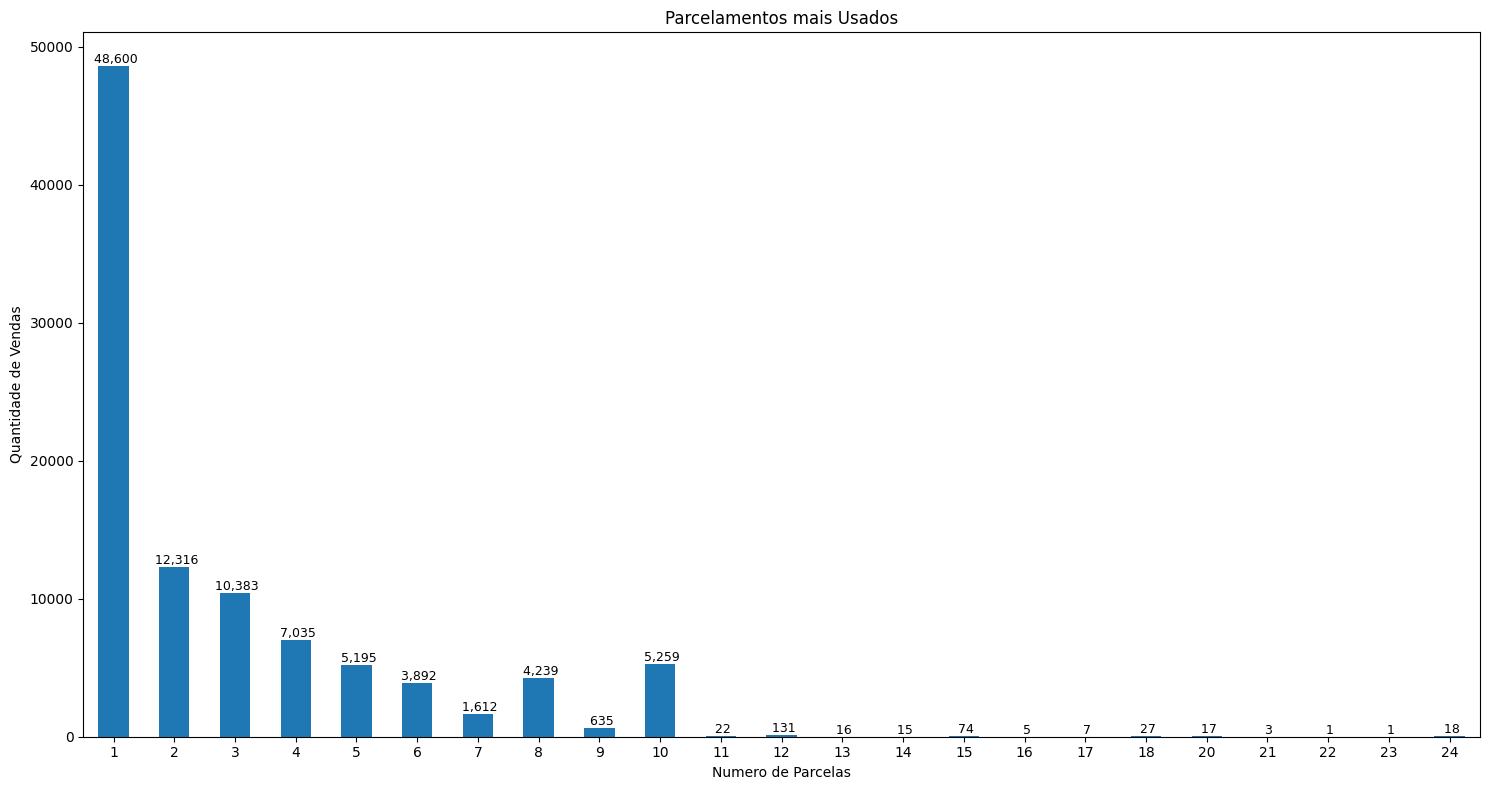

In [137]:
ax = parcelamentos.sort_values(by='payment_installments', ascending=True).plot(kind='bar', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                
        f' {bar.get_height():,.0f}',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.title('Parcelamentos mais Usados')
plt.xlabel('Numero de Parcelas')
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=0, ha='center')
plt.legend().remove()
plt.tight_layout()
plt.show()

## 7. Monthly Seasonality

In [ ]:
# Ha sazonalidade nas vendas por mes?
df_sales['month'] = df_sales['order_purchase_timestamp'].dt.month

vendas_por_mes = (df_sales[df_sales['order_purchase_timestamp'].dt.year == 2017]
    .groupby('month')['order_id'].nunique().to_frame().sort_index())

vendas_por_mes.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
vendas_por_mes.sort_values(by='order_id', ascending=False)

,order_id
Nov,7451
Dec,5624
Oct,4568
Aug,4291
Sep,4243
Jul,3967
May,3660
Jun,3215
Mar,2638
Apr,2385


> **Nota:** analise filtrada para 2017 por ser o unico ano completo no dataset.
> Anos de 2016 e 2018 foram descartados pois possuem dados incompletos e
> distorceriam a analise de sazonalidade.

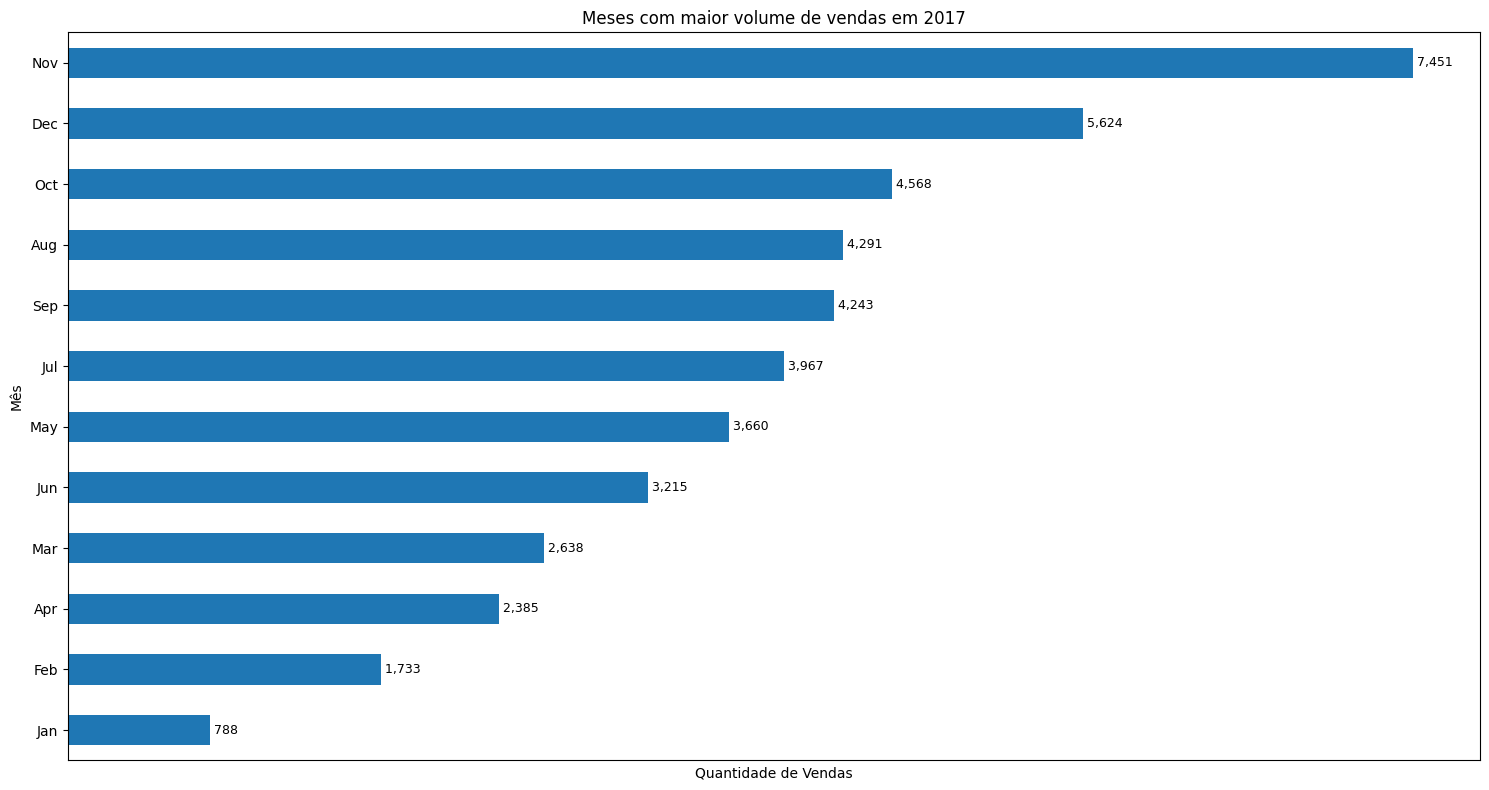

In [150]:
ax = vendas_por_mes.sort_values(by='order_id', ascending=True).plot(kind='barh', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f' {int(bar.get_width()):,}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.title('Meses com maior volume de vendas em 2017')
plt.xlabel('Quantidade de Vendas')
plt.ylabel('Mês')
plt.legend().remove()
plt.xticks([])
plt.tight_layout()
plt.show()

## 8. Orders by Day of Week

In [153]:
# Quais os dias da semana com mais pedidos?
df_sales['weekday'] = df_sales['order_purchase_timestamp'].dt.weekday
pedidos_semana = df_sales.groupby('weekday')['order_id'].nunique().to_frame().sort_index()
pedidos_semana.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pedidos_semana.sort_values(by='order_id', ascending=False)

,order_id
Monday,16064
Tuesday,15829
Wednesday,15423
Thursday,14635
Friday,14001
Sunday,11881
Saturday,10808


> **Insight:** segunda-feira e o dia com maior volume de pedidos, com queda
> progressiva ao longo da semana. Fins de semana representam os menores volumes,
> sugerindo que o consumidor brasileiro compra principalmente durante dias uteis.

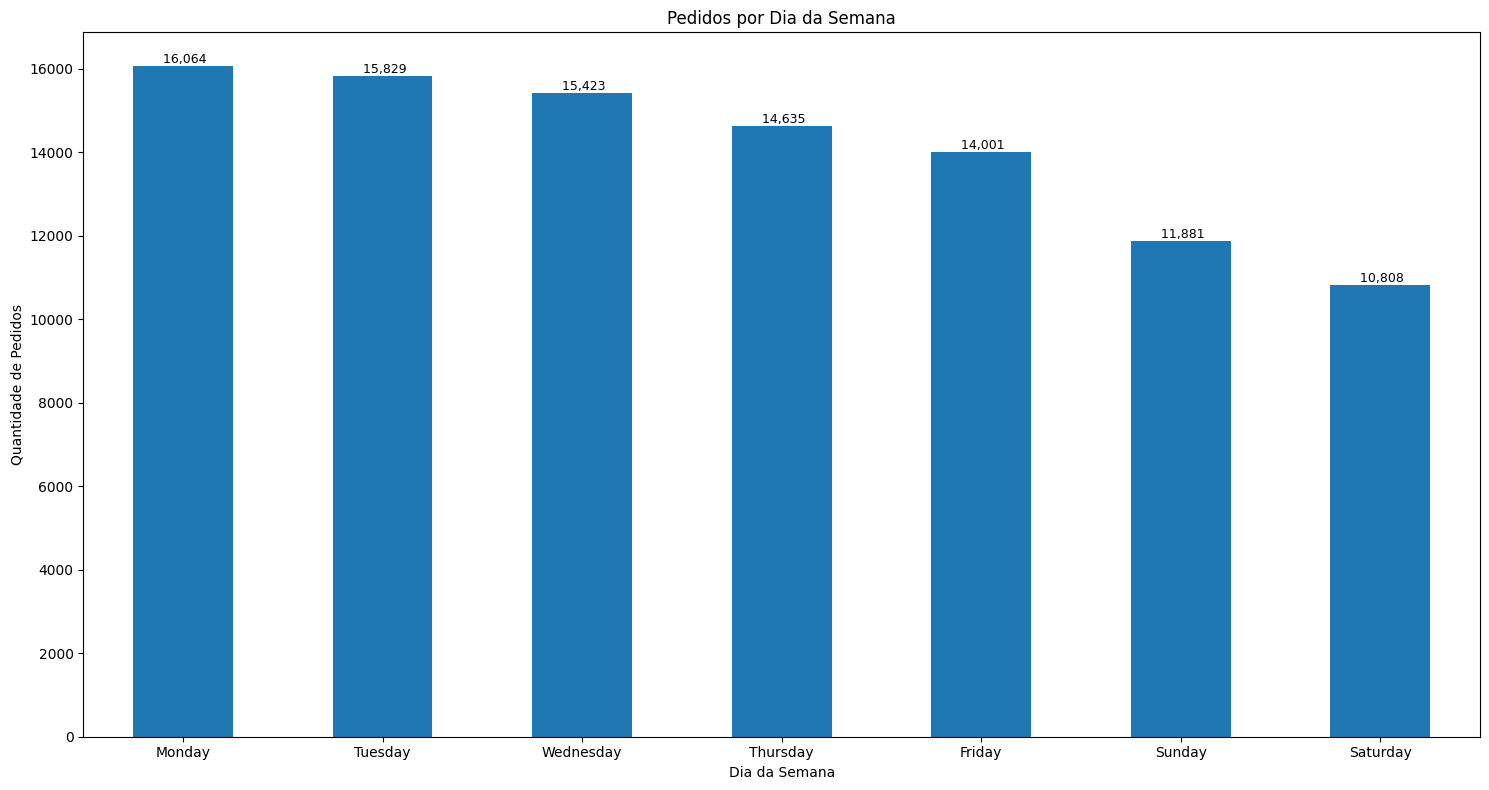

In [155]:
ax = pedidos_semana.sort_values(by='order_id', ascending=False).plot(kind='bar', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                
        f' {bar.get_height():,.0f}',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.title('Pedidos por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Pedidos')
plt.xticks(rotation=0, ha='center')
plt.legend().remove()
plt.tight_layout()
plt.show()

## 9. Average Revenue by Month

In [158]:
# Qual a receita media por mes?
df_sales['month'] = df_sales['order_purchase_timestamp'].dt.month

receita_media_mes = (df_sales[df_sales['order_purchase_timestamp'].dt.year == 2017]
    .drop_duplicates(subset=['order_id', 'payment_value'])
    .groupby('month')['payment_value'].mean().to_frame().sort_index())

receita_media_mes.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
receita_media_mes.sort_values(by='payment_value', ascending=False)

,payment_value
Apr,162.621548
Sep,162.393463
Jan,161.903685
Oct,161.015803
Feb,157.366156
Mar,155.535512
Nov,152.614519
May,150.893164
Aug,149.753081
Jun,148.364653


In [162]:
# Categorias mais vendidas em abril de 2017

(df_sales[(df_sales['order_purchase_timestamp'].dt.year == 2017) & 
          (df_sales['order_purchase_timestamp'].dt.month == 4)]
    .groupby('product_category_name_english')['order_item_id']
    .count()
    .to_frame()
    .sort_values(by='order_item_id', ascending=False)
    .head(10))

,order_item_id
product_category_name_english,
bed_bath_table,307
sports_leisure,224
furniture_decor,213
health_beauty,193
housewares,191
garden_tools,150
telephony,149
computers_accessories,140
cool_stuff,130


> **Nota:** a investigacao das categorias de abril nao revelou padrao especifico
> de sazonalidade. O ticket medio alto pode ser explicado pela maior participacao
> de categorias com ticket naturalmente elevado como furniture_decor e
> computers_accessories.

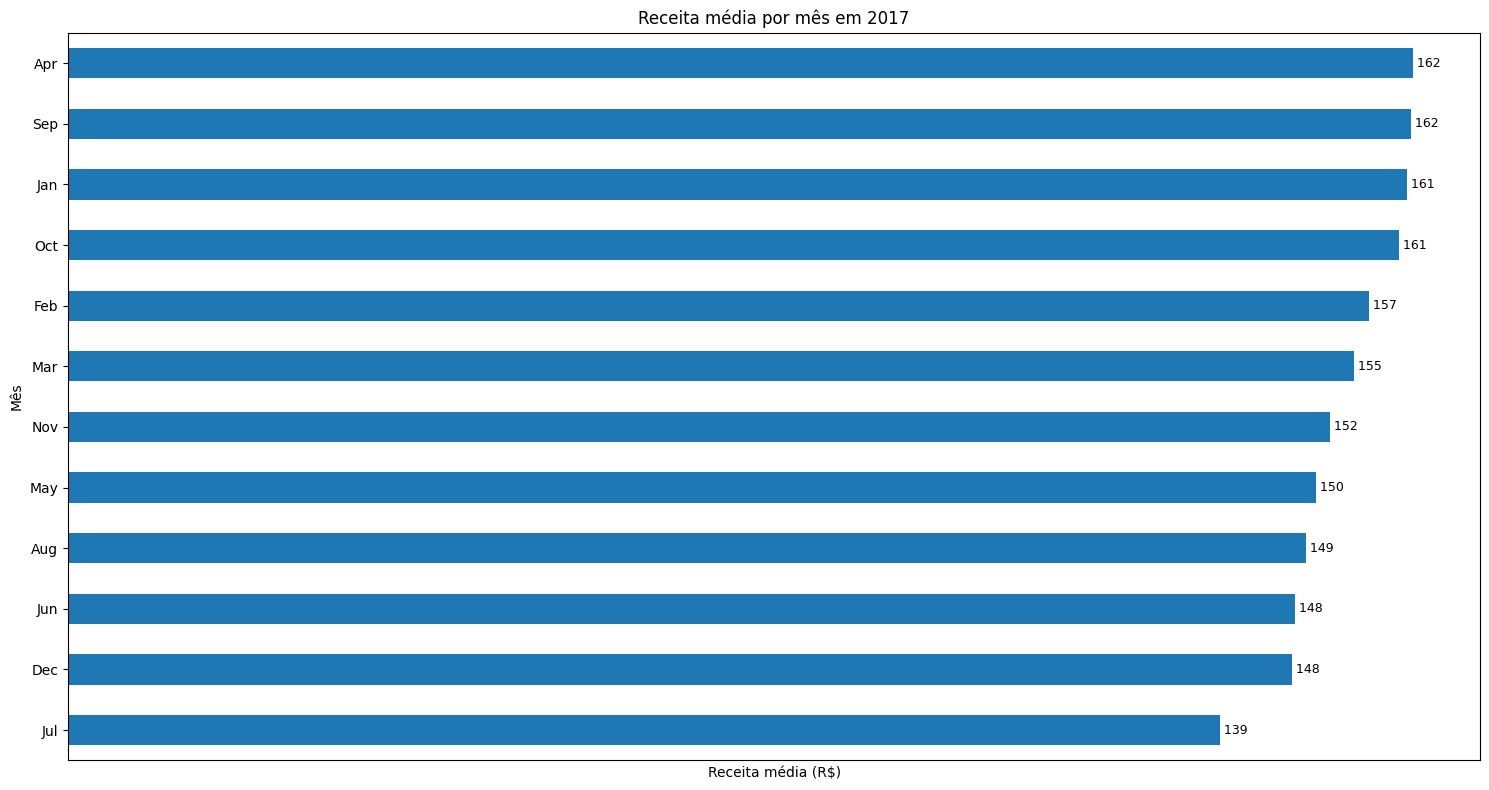

In [164]:
ax = receita_media_mes.sort_values(by='payment_value', ascending=True).plot(kind='barh', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f' {int(bar.get_width()):,}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.title('Receita média por mês em 2017')
plt.xlabel('Receita média (R$)')
plt.ylabel('Mês')
plt.legend().remove()
plt.xticks([])
plt.tight_layout()
plt.show()

## 10. Freight Value by Category

In [178]:
# Quais categorias tem o maior valor de frete?
frete_categoria = (order_items.merge(products[['product_id', 'product_category_name']], on='product_id')
    .merge(product_category, on='product_category_name')
    .groupby('product_category_name_english')['freight_value'].mean().to_frame().sort_values(by='freight_value', ascending=False))

frete_categoria

,freight_value
product_category_name_english,
computers,48.454680
home_appliances_2,44.538571
furniture_mattress_and_upholstery,42.906842
kitchen_dining_laundry_garden_furniture,42.702598
furniture_bedroom,42.497523
...,...
food,14.256922
home_comfort_2,13.677000
fashio_female_clothing,12.953125


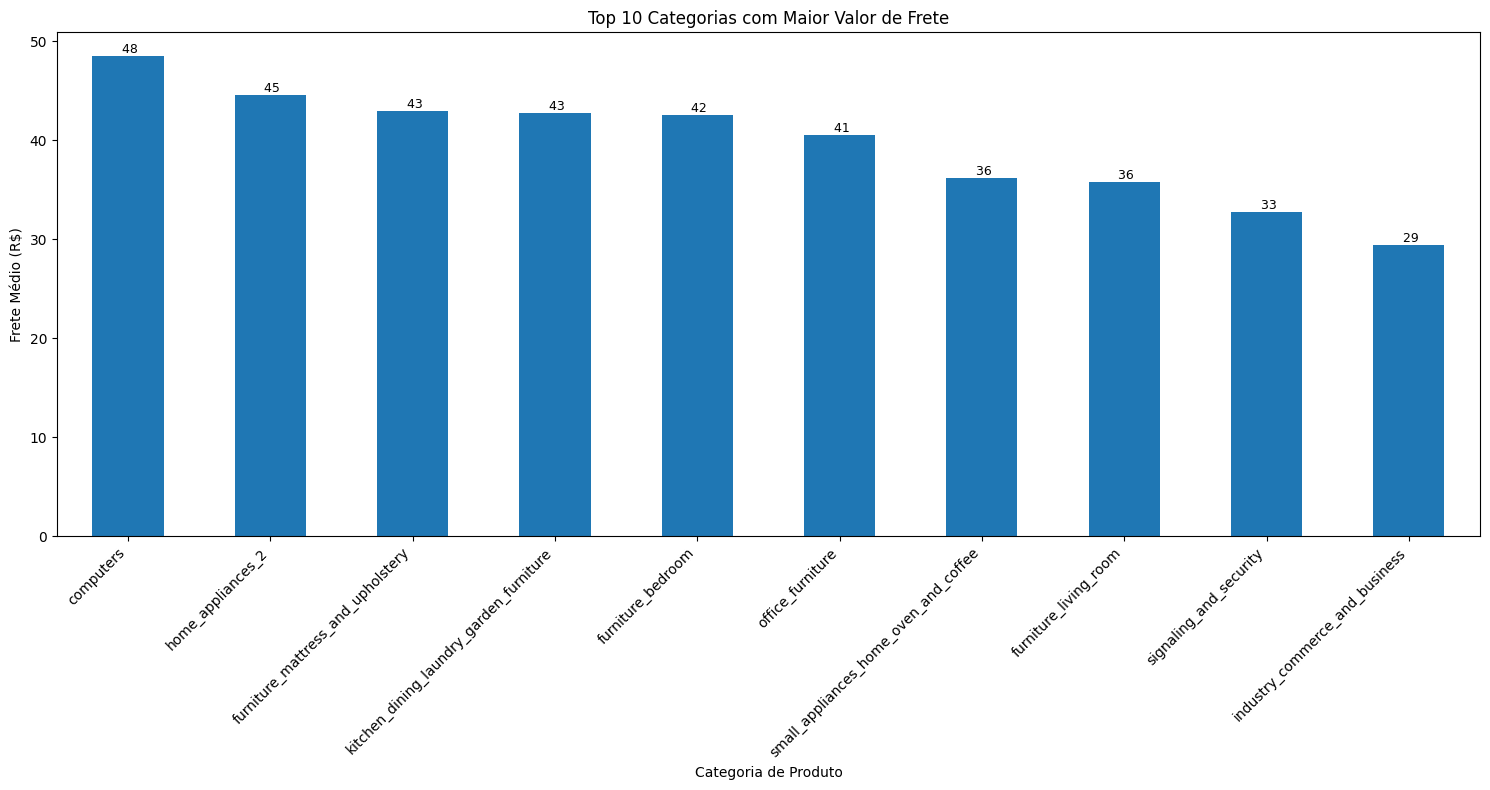

In [181]:
ax = frete_categoria.head(10).sort_values(by='freight_value', ascending=False).plot(kind='bar', figsize=(15, 8))

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                
        f' {bar.get_height():,.0f}',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.title('Top 10 Categorias com Maior Valor de Frete')
plt.xlabel('Categoria de Produto')
plt.ylabel('Frete Médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.legend().remove()
plt.tight_layout()
plt.show()